<a href="https://colab.research.google.com/github/sowmyasri23/Image-Slider/blob/main/CNN_digit_classifier.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
tf.random.set_seed(RANDOM_STATE)

In [ ]:
digits = load_digits()
X = digits.images
y = digits.target

print(f"Dataset size: {X.shape[0]} images, {len(np.unique(y))} classes")
print(f"Image shape: {X.shape[1]}x{X.shape[2]}")

X = X.astype("float32") / 16.0
X = X.reshape(-1, 8, 8, 1)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

print(f"Train samples: {X_train.shape[0]} | Test samples: {X_test.shape[0]}")

Dataset size: 1797 images, 10 classes
Image shape: 8x8
Train samples: 1437 | Test samples: 360


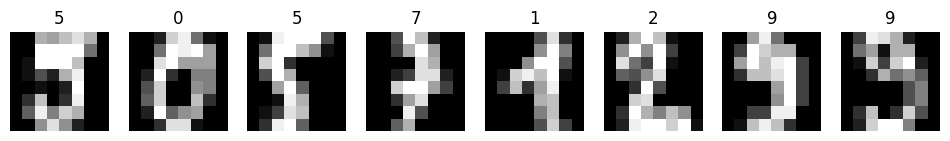

In [ ]:
fig, axes = plt.subplots(1, 8, figsize=(12, 2))
for ax, img, label in zip(axes, X_train[:8], y_train[:8]):
    ax.imshow(img.reshape(8, 8), cmap="gray")
    ax.set_title(str(label))
    ax.axis("off")
plt.show()

In [ ]:
model = keras.Sequential([
    layers.Input(shape=(8, 8, 1)),
    layers.Conv2D(32, (3, 3), activation="relu", padding="same"),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation="relu", padding="same"),
    layers.Dropout(0.3),
    layers.Flatten(),
    layers.Dense(64, activation="relu"),
    layers.Dropout(0.3),
    layers.Dense(10, activation="softmax"),
])

model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

model.summary()

history = model.fit(
    X_train, y_train, validation_data=(X_test, y_test), batch_size=64, epochs=50
)

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 8, 8, 32)       │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 4, 4, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 4, 4, 64)       │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 4, 4, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │        65,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 85,066 (332.29 KB)

 Trainable params: 85,066 (332.29 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - accuracy: 0.3076 - loss: 2.1155 - val_accuracy: 0.6944 - val_loss: 1.7304
Epoch 2/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.5999 - loss: 1.3910 - val_accuracy: 0.8444 - val_loss: 0.7888
Epoch 3/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.7683 - loss: 0.7793 - val_accuracy: 0.8861 - val_loss: 0.4261
Epoch 4/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.8337 - loss: 0.5219 - val_accuracy: 0.9028 - val_loss: 0.3041
Epoch 5/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.8706 - loss: 0.4098 - val_accuracy: 0.9333 - val_loss: 0.2143
Epoch 6/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.9137 - loss: 0.3092 - val_accuracy: 0.9556 - val_loss: 0.1744
Epoch 7/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.9214 - loss: 0.2654 - val_accuracy: 0.9500 - val_loss: 0.1526
Epoch 8/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.9311 - loss: 0.2379 - val_accuracy: 0.9583 - v

In [ ]:
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
print(f"Final Test Accuracy: {test_acc*100:.2f}%")
print(f"Final Test Loss: {test_loss:.4f}")

y_pred = np.argmax(model.predict(X_test, verbose=0), axis=1)
print("\nClassification Report:")
print(classification_report(y_test, y_pred, digits=4))

Final Test Accuracy: 3.89%
Final Test Loss: 2.3106

Classification Report:
              precision    recall  f1-score   support

           0     0.0581    0.2500    0.0942        36
           1     0.0000    0.0000    0.0000        36
           2     0.0000    0.0000    0.0000        35
           3     0.1667    0.0270    0.0465        37
           4     0.0000    0.0000    0.0000        36
           5     0.0000    0.0000    0.0000        37
           6     0.0069    0.0278    0.0111        36
           7     0.0714    0.0833    0.0769        36
           8     0.0000    0.0000    0.0000        35
           9     0.0000    0.0000    0.0000        36

    accuracy                         0.0389       360
   macro avg     0.0303    0.0388    0.0229       360
weighted avg     0.0308    0.0389    0.0230       360



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


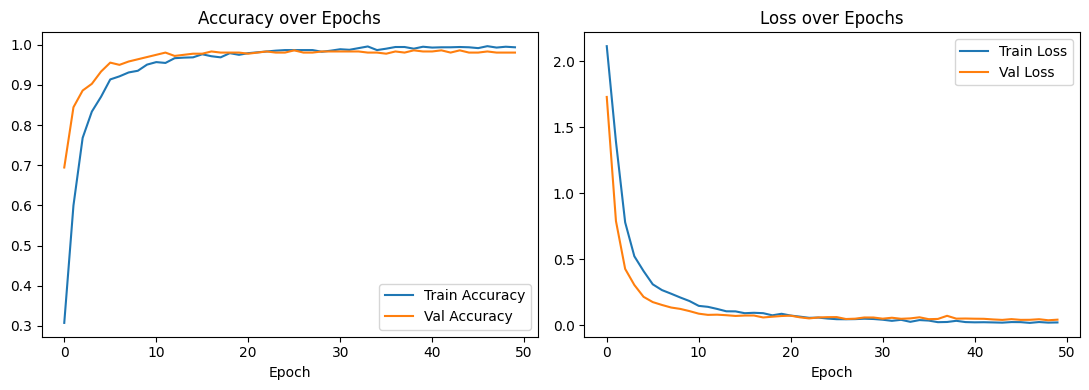

In [ ]:
# Training curves
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(history.history["accuracy"], label="Train Accuracy")
axes[0].plot(history.history["val_accuracy"], label="Val Accuracy")
axes[0].set_title("Accuracy over Epochs")
axes[0].set_xlabel("Epoch")
axes[0].legend()

axes[1].plot(history.history["loss"], label="Train Loss")
axes[1].plot(history.history["val_loss"], label="Val Loss")
axes[1].set_title("Loss over Epochs")
axes[1].set_xlabel("Epoch")
axes[1].legend()
plt.tight_layout()
plt.savefig("training_curves.png", dpi=150)
plt.show()

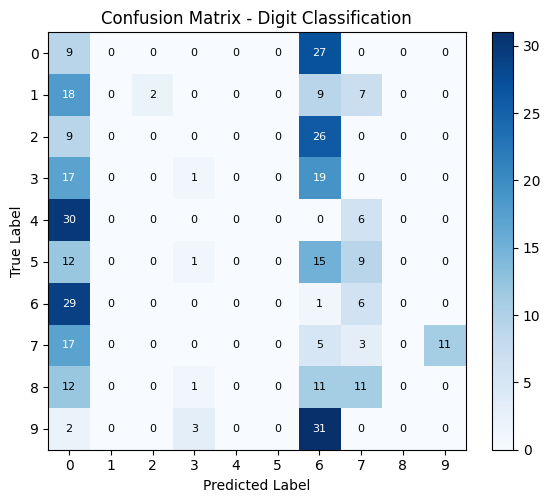

In [ ]:
# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(cm, cmap="Blues")
ax.set_xticks(range(10))
ax.set_yticks(range(10))
ax.set_xlabel("Predicted Label")
ax.set_ylabel("True Label")
ax.set_title("Confusion Matrix - Digit Classification")
for i in range(10):
    for j in range(10):
        ax.text(j, i, cm[i, j], ha="center", va="center",
                 color="white" if cm[i, j] > cm.max()/2 else "black", fontsize=8)
plt.colorbar(im)
plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=150)
plt.show()

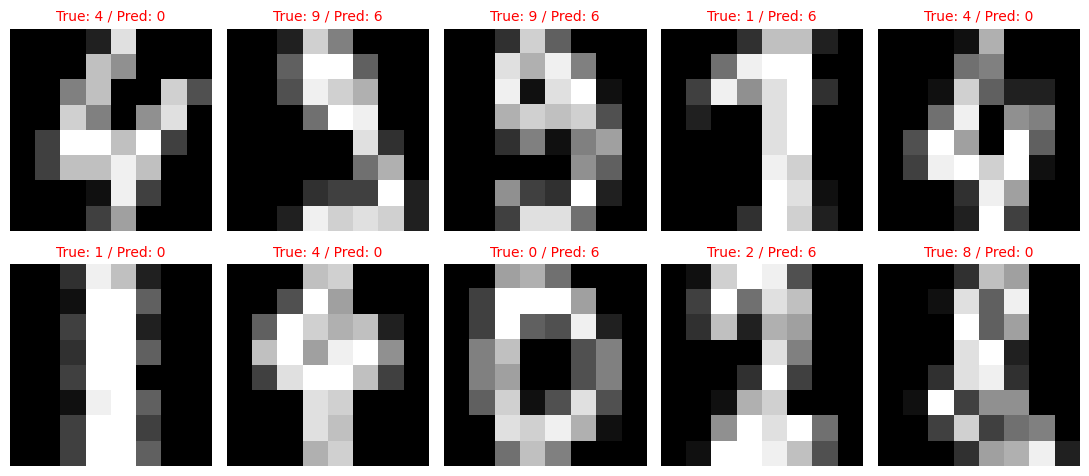

In [ ]:
# Sample predictions
fig, axes = plt.subplots(2, 5, figsize=(11, 5))
sample_idx = np.random.choice(len(X_test), 10, replace=False)
for ax, idx in zip(axes.flat, sample_idx):
    ax.imshow(X_test[idx].reshape(8, 8), cmap="gray")
    color = "green" if y_pred[idx] == y_test[idx] else "red"
    ax.set_title(f"True: {y_test[idx]} / Pred: {y_pred[idx]}", color=color, fontsize=10)
    ax.axis("off")
plt.tight_layout()
plt.savefig("sample_predictions.png", dpi=150)
plt.show()

In [ ]:
model.save("digit_cnn_model.h5")
print("Model saved as digit_cnn_model.h5")

# Uncomment the two lines below to auto-download the model file to your computer
# from google.colab import files
# files.download("digit_cnn_model.h5")

Model saved as digit_cnn_model.h5


In [ ]:
!pkill -f streamlit
!pkill -f localtunnel

In [ ]:
!wget -q https://github.com/cloudflare/cloudflared/releases/latest/download/cloudflared-linux-amd64 -O cloudflared
!chmod +x cloudflared

In [ ]:
import subprocess, time

# Start Streamlit in the background
subprocess.Popen(["streamlit", "run", "app.py", "--server.port", "8501"],
                  stdout=open("/content/logs.txt", "a"), stderr=subprocess.STDOUT)
time.sleep(8)  # give Streamlit time to fully start

# Start Cloudflare tunnel pointing at it
!./cloudflared tunnel --url http://localhost:8501

2026-07-05T04:54:43Z INF Thank you for trying Cloudflare Tunnel. Doing so, without a Cloudflare account, is a quick way to experiment and try it out. However, be aware that these account-less Tunnels have no uptime guarantee, are subject to the Cloudflare Online Services Terms of Use (https://www.cloudflare.com/website-terms/), and Cloudflare reserves the right to investigate your use of Tunnels for violations of such terms. If you intend to use Tunnels in production you should use a pre-created named tunnel by following: https://developers.cloudflare.com/cloudflare-one/connections/connect-apps
2026-07-05T04:54:43Z INF Requesting new quick Tunnel on trycloudflare.com...
2026-07-05T04:54:46Z INF +--------------------------------------------------------------------------------------------+
2026-07-05T04:54:46Z INF |  Your quick Tunnel has been created! Visit it at (it may take some time to be reachable):  |
2026-07-05T04:54:46Z INF |  https://pays-teach-end-firms.trycloudflare.com       